Shape: (891, 12)

Null values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Survived value counts:
 Survived
0    549
1    342
Name: count, dtype: int64


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,0
1,1,1,0,38.0,1,0,71.2833,1
2,1,3,0,26.0,0,0,7.9250,0
3,1,1,0,35.0,1,0,53.1000,0
4,0,3,1,35.0,0,0,8.0500,0


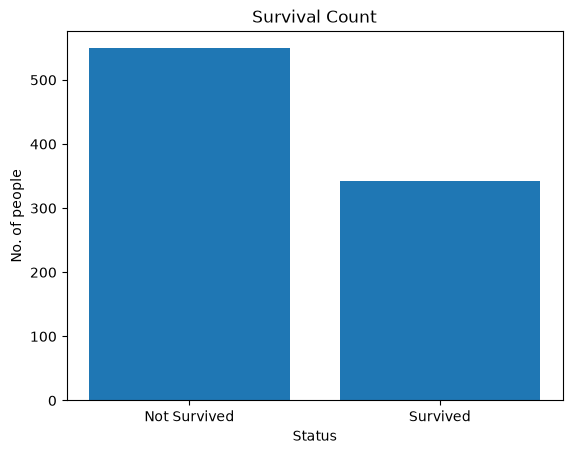

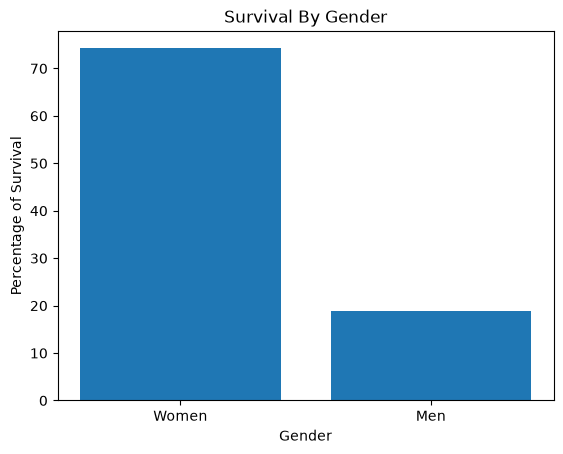

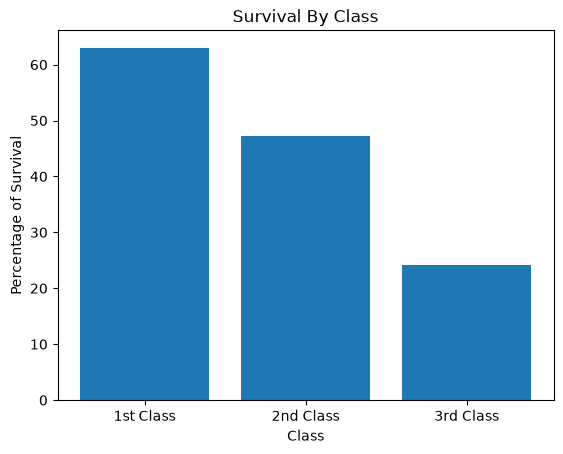

Accuracy: 0.80

Confusion matrix: 
[[89 16]
 [20 54]]
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



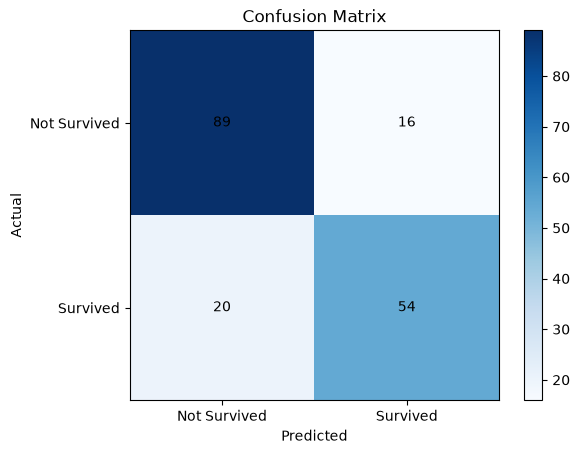

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

# Loading data and exploring data

df = pd.read_csv('train.csv')
print("Shape:", df.shape)
print("\nNull values:\n", df.isnull().sum())
print("\nSurvived value counts:\n", df['Survived'].value_counts())

# Data Cleaning

df = df.drop(columns=['PassengerId','Name','Cabin','Ticket'])
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Sex'] = df['Sex'].map({'male':1,'female':0})
df['Embarked'] = df['Embarked'].map({'S':0,'C':1,'Q':2})
display(df.head())

# EDA

plt.bar(["Not Survived","Survived"],df['Survived'].value_counts())
plt.xlabel('Status')
plt.ylabel('No. of people')
plt.title('Survival Count')
plt.show()

plt.bar(["Women","Men"],df.groupby('Sex')['Survived'].mean()*100)
plt.xlabel('Gender')
plt.ylabel('Percentage of Survival')
plt.title("Survival By Gender")
plt.show()

plt.bar(['1st Class','2nd Class','3rd Class'],df.groupby('Pclass')['Survived'].mean()*100)
plt.xlabel('Class')
plt.ylabel('Percentage of Survival')
plt.title('Survival By Class')
plt.show()

# splitting data into train and test

y = df['Survived']
X = df.drop(columns='Survived')
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Scaling Data

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Training Model

model = LogisticRegression()
model.fit(X_train_sc,y_train)
y_pred = model.predict(X_test_sc)

# Evaluation 

acc = accuracy_score(y_test,y_pred)
print(f"Accuracy: {acc:.2f}")
conf_m = confusion_matrix(y_test,y_pred)
print(f"\nConfusion matrix: \n{conf_m}")
print(classification_report(y_test, y_pred))

# Confusion Matrix as HeatMap

plt.imshow(conf_m, cmap='Blues')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.xticks([0,1], ['Not Survived', 'Survived'])
plt.yticks([0,1], ['Not Survived', 'Survived'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, conf_m[i,j], ha='center', va='center')

plt.show() 